In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

In [2]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
import data as dt, models as md, backtest as bt
output_dir = Path("../Outputs")
output_dir.mkdir(exist_ok=True)
print("Imports OK")

Imports OK


In [3]:
airline_returns, macro_returns, prices = dt.load_data()
airline_returns = airline_returns[airline_returns.index >= dt.test_start]
macro_returns = macro_returns[macro_returns.index >= dt.test_start]
print(f"Running validation period only: "f"{airline_returns.index[0].date()} → "f"{airline_returns.index[-1].date()}")
best_window = 180

zscore_window = 45
n_components = md.n_components

covs = md.rolling_covariances(airline_returns,window=best_window,use_ledoit_wolf=True)
_, residuals, _, _, _ = md.compute_factor_model(airline_returns,covs,n_components)

pc1 = md.compute_pc1_concentration(covs)

zscores = md.compute_rolling_zscore(residuals,window=zscore_window).dropna()

Airlines: 7 tickers
Macro: 4 tickers
Dates: 2903 trading days
Range: 2015-01-05 -> 2026-07-16
Training: 2015-01-05 -> 2019-12-31
Validation: 2022-01-01 -> 2026-07-16
Running validation period only: 2022-01-03 → 2026-07-16


In [4]:
print("Signal Generation Sanity Check")
print(f"Entry threshold: {bt.entry_threshold}")
print(f"Exit threshold: {bt.exit_threshold}")
print(f"Z-score max: {zscores.abs().max().max():.3f}")
print(f"Z-score 95th pct: {zscores.abs().quantile(0.95).mean():.3f}")
pct_above = (zscores.abs() > bt.entry_threshold).mean().mean()
print(f"% days above threshold: {pct_above:.2%}")
if pct_above < 0.01:
    print("WARNING: < 1% of days generate signals — lower threshold or remove EMA")
elif pct_above > 0.20:
    print("WARNING: > 20% of days generate signals — raise threshold")
else:
    print("OK: signal frequency in acceptable range")

Signal Generation Sanity Check
Entry threshold: 1.75
Exit threshold: 0.75
Z-score max: 5.817
Z-score 95th pct: 2.040
% days above threshold: 7.74%
OK: signal frequency in acceptable range


In [5]:
signals = bt.generate_signals(zscores,
                              entry = bt.entry_threshold,
                              exit_ = bt.exit_threshold,
                              top_n = bt.top_n,
                              min_hold = bt.min_hold_days,
                              momentum = False,
                             )
active = (signals != 0).any(axis=1)
print(f"Active days: {active.sum()} / {len(signals)} ({active.mean():.1%})")
print(f"\nSignal value counts:")
print(signals.stack().value_counts())
signals.head()

Active days: 708 / 952 (74.4%)

Signal value counts:
 0.0    5556
-1.0     572
 1.0     536
Name: count, dtype: int64


,DAL,UAL,AAL,LUV,ALK,JBLU,CPA
2022-10-04,-1.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-10-05,-1.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-10-06,-1.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-10-07,-1.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-10-10,-1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
holding_periods = []
for col in signals.columns:
    s = signals[col]
    in_pos = False
    count = 0
    for val in s:
        if val != 0:
            count += 1
            in_pos = True
        elif in_pos:
            holding_periods.append(count)
            count = 0
            in_pos = False
    if in_pos and count > 0:
        holding_periods.append(count)

if len(holding_periods) == 0:
    print("No completed positions found.")
    print("Either no signals fired or all positions still open.")
else:
    holding_s = pd.Series(holding_periods)
    print(f"Holding period distribution:")
    print(f"Min: {holding_s.min():.0f} days (should be ≥ 5)")
    print(f"Median: {holding_s.median():.0f} days")
    print(f"Mean: {holding_s.mean():.1f} days")
    print(f"Max: {holding_s.max():.0f} days")
    print(f"Positions shorter than 5 days: {(holding_s < 5).sum()}")

Holding period distribution:
Min: 1 days (should be ≥ 5)
Median: 4 days
Mean: 3.8 days
Max: 13 days
Positions shorter than 5 days: 151


In [7]:
active_days = signals[signals.abs().sum(axis=1) > 0]
positions_per_day = signals.abs().sum(axis=1)
print(f"Position count distribution:")
print(positions_per_day[positions_per_day > 0].value_counts().sort_index())

Position count distribution:
1.0    308
2.0    400
Name: count, dtype: int64


In [8]:
rolling_q95 = zscores.abs().rolling(45).quantile(0.95)
print("Rolling 95th percentile of |z-scores|:")
print(rolling_q95.describe().round(3))
print(f"\nFixed threshold 1.25 corresponds to approx the "
      f"{(zscores.abs() > 1.25).mean().mean()*100:.1f}th percentile of your data")

Rolling 95th percentile of |z-scores|:
           DAL      UAL      AAL      LUV      ALK     JBLU      CPA
count  908.000  908.000  908.000  908.000  908.000  908.000  908.000
mean     1.991    1.875    1.857    1.868    1.864    1.939    1.951
std      0.389    0.293    0.354    0.441    0.406    0.393    0.495
min      1.079    1.151    0.991    0.898    0.869    1.134    0.602
25%      1.707    1.695    1.624    1.547    1.582    1.658    1.690
50%      1.958    1.895    1.853    1.886    1.949    1.853    1.938
75%      2.277    2.038    2.113    2.087    2.117    2.183    2.134
max      2.781    2.649    3.221    3.619    2.931    2.906    3.243

Fixed threshold 1.25 corresponds to approx the 17.0th percentile of your data


In [9]:
positions_raw = bt.construct_portfolio(signals, zscores = zscores, residuals = residuals)
positions = bt.apply_continuous_concentration_scaling(positions_raw, pc1)
positions = bt.apply_macro_regime_filter(positions, macro_returns, vix_window = 120, brent_window = 120, vix_scale_q3 = 1.0, vix_close_q4 = 0.25, brent_close_q4 = 0.5)
print(f"Gross exposure after regime filter: {positions.abs().sum(axis=1).mean():.3f}")
print(f"Net exposure mean: {positions.sum(axis = 1).abs().mean():.6f}")
print(f"Gross exposure mean: {positions.abs().sum(axis=1).mean():.3f}")

Macro regime filter: full=240d  half=301d closed=411d
Gross exposure after regime filter: 0.111
Net exposure mean: 0.034851
Gross exposure mean: 0.111


In [10]:
net_returns, trades = bt.compute_portfolio_returns(positions, airline_returns)
print(f"Ann. turnover: {trades['turnover'].mean()*252:.2f}")
print(f"Ann. cost drag: {trades['transaction_cost'].mean()*252:.2%}")
print(f"Active days: {(net_returns != 0).sum()}")
trades.head()

Ann. turnover: 10.92
Ann. cost drag: 1.09%
Active days: 694


,gross_return,turnover,transaction_cost,net_return,n_longs,n_shorts,gross_exposure
2022-10-04,0.0,0.0,0.0,0.0,0,0,0.0
2022-10-05,0.0,0.0,0.0,0.0,0,0,0.0
2022-10-06,0.0,0.0,0.0,0.0,0,0,0.0
2022-10-07,0.0,0.0,0.0,0.0,0,0,0.0
2022-10-10,0.0,0.0,0.0,0.0,0,0,0.0


In [11]:
perf = bt.compute_performance(net_returns, trades, macro_returns)
perf.to_frame("strategy")

,strategy
annualized_returns,0.0137
annualized_volatility,0.0494
sharpe_ratio,0.2770
max_drawdown,-0.0772
calmar_ratio,0.1780
hit_rate,0.4467
ann_turnover,10.9250
active_days,694.0000
total_days,952.0000
spy_alpha_annual,0.0132


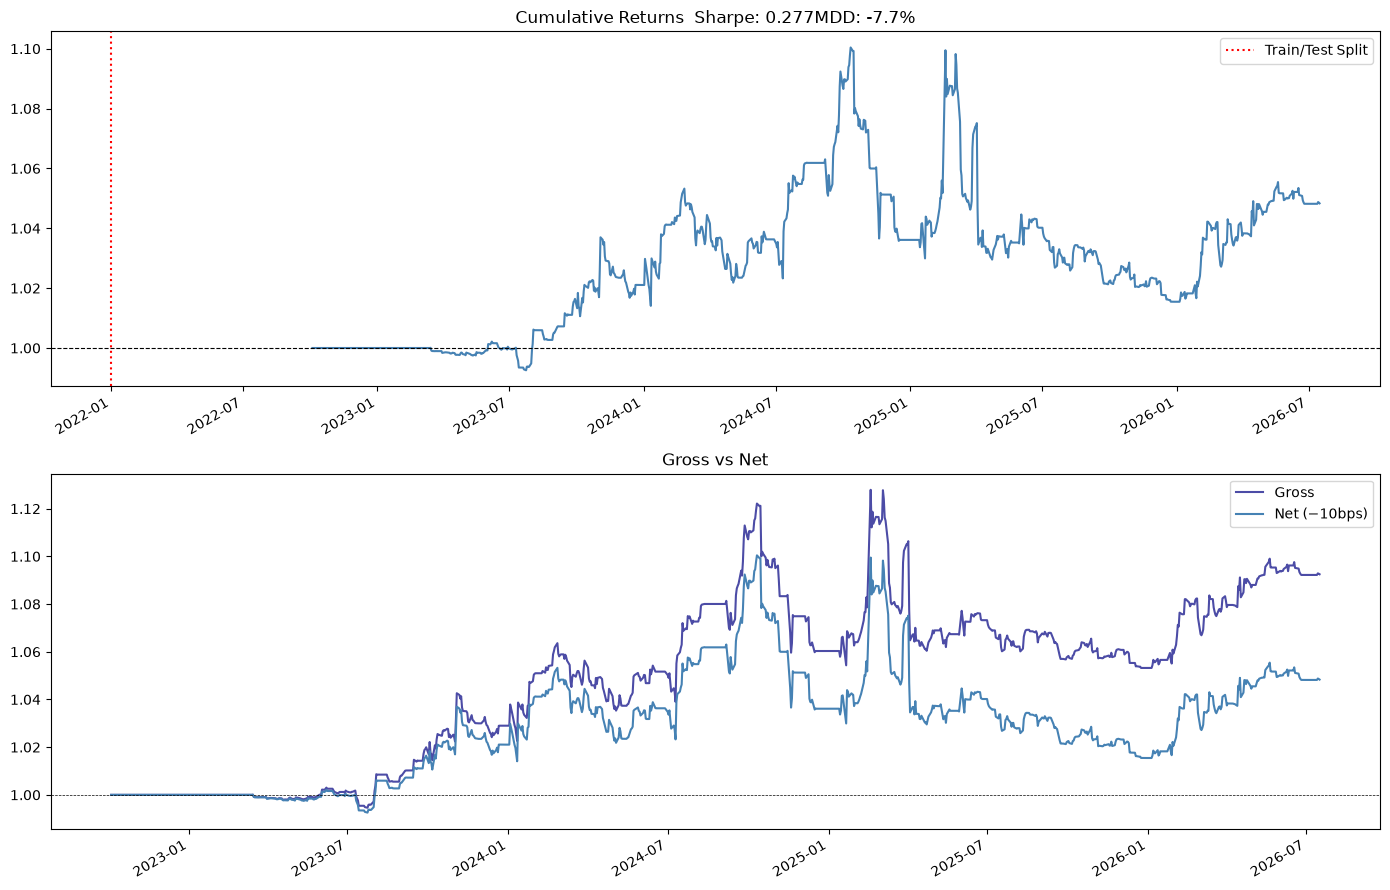

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

(1 + net_returns).cumprod().plot(ax=axes[0], color='steelblue', linewidth=1.5)
axes[0].axhline(1.0, color='black', linestyle='--', linewidth=0.8)
axes[0].axvline(pd.Timestamp(dt.test_start), color='red',
                linestyle=':', label='Train/Test Split')
axes[0].set_title(f"Cumulative Returns  Sharpe: {perf['sharpe_ratio']:.3f}"
                  f"MDD: {perf['max_drawdown']:.1%}")
axes[0].legend()

# Gross vs net
(1 + trades['gross_return']).cumprod().plot(ax=axes[1],
    label='Gross', alpha=0.7, color='navy')
(1 + trades['net_return']).cumprod().plot(ax=axes[1],
    label='Net (−10bps)', color='steelblue', linewidth=1.5)
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=0.5)
axes[1].legend()
axes[1].set_title("Gross vs Net")
plt.tight_layout()
plt.show()

In [13]:
diag = bt.macro_regime_diagnostics(net_returns, macro_returns)
print("Sharpe by Macro Regime Quartile:")
print(diag.to_string())

Sharpe by Macro Regime Quartile:
          Q1     Q2     Q3     Q4
VIX   -1.350 -1.171  1.733  1.042
Brent -1.336 -0.112  1.014  1.150


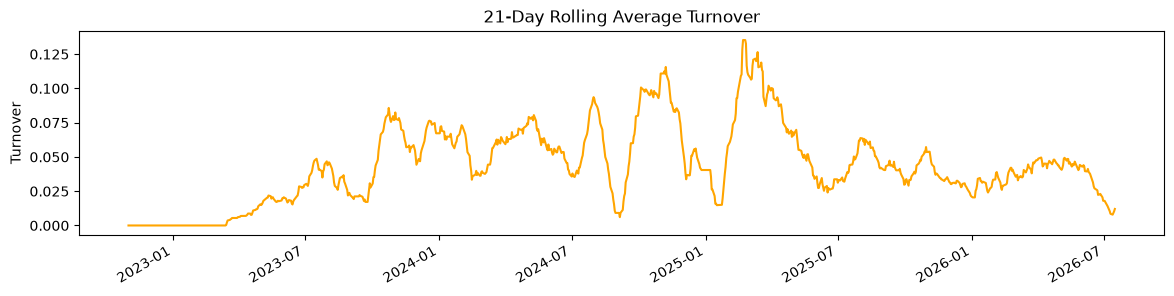

Avg daily turnover: 0.0434
Avg annual turnover: 10.92x


In [14]:
trades['turnover'].rolling(21).mean().plot(
    figsize=(14, 3), color='orange',
    title="21-Day Rolling Average Turnover"
)
plt.ylabel("Turnover")
plt.show()
print(f"Avg daily turnover: {trades['turnover'].mean():.4f}")
print(f"Avg annual turnover: {trades['turnover'].mean()*252:.2f}x")

In [15]:
net_returns.to_frame("net_return").to_csv(output_dir / "net_returns.csv")
perf.to_frame("strategy").to_csv(output_dir  / "performance.csv")
positions.to_csv(output_dir / "signals.csv")
trades.to_csv(output_dir / "trades.csv")
print("Saved.")

Saved.


In [16]:
windows = [20,30,45,60,75,90]

for w in windows:

    z = md.compute_rolling_zscore(residuals,window=w).dropna()
    signals = bt.generate_signals(z, top_n=bt.top_n, exit_=bt.exit_threshold, min_hold=bt.min_hold_days, momentum=False)
    pc1 = md.compute_pc1_concentration(covs)
    positions_raw = bt.construct_portfolio(signals, zscores = z, residuals=residuals)
    positions = bt.apply_continuous_concentration_scaling(positions_raw, pc1,)
    positions = bt.apply_macro_regime_filter(positions, macro_returns, vix_window = 120, brent_window = 120, vix_scale_q3 = 1.0, vix_close_q4 = 0.25, brent_close_q4 = 0.5)
    net, trades = bt.compute_portfolio_returns(positions, airline_returns)
    perf = bt.compute_performance(net, trades, macro_returns)
    print(f"\nWindow = {w}")
    print(perf[["annualized_returns", "sharpe_ratio", "ann_turnover"]])

Macro regime filter: full=240d  half=301d closed=411d

Window = 20
annualized_returns    -0.007
sharpe_ratio          -0.154
ann_turnover          11.845
dtype: float64
Macro regime filter: full=240d  half=301d closed=411d

Window = 30
annualized_returns    -0.0098
sharpe_ratio          -0.1940
ann_turnover          11.3450
dtype: float64
Macro regime filter: full=240d  half=301d closed=411d

Window = 45
annualized_returns     0.0137
sharpe_ratio           0.2770
ann_turnover          10.9250
dtype: float64
Macro regime filter: full=240d  half=301d closed=411d

Window = 60
annualized_returns     0.0025
sharpe_ratio           0.0590
ann_turnover          10.5660
dtype: float64
Macro regime filter: full=240d  half=301d closed=411d

Window = 75
annualized_returns    -0.0018
sharpe_ratio          -0.0400
ann_turnover          10.2120
dtype: float64
Macro regime filter: full=240d  half=301d closed=411d

Window = 90
annualized_returns    -0.0121
sharpe_ratio          -0.2680
ann_turnover    